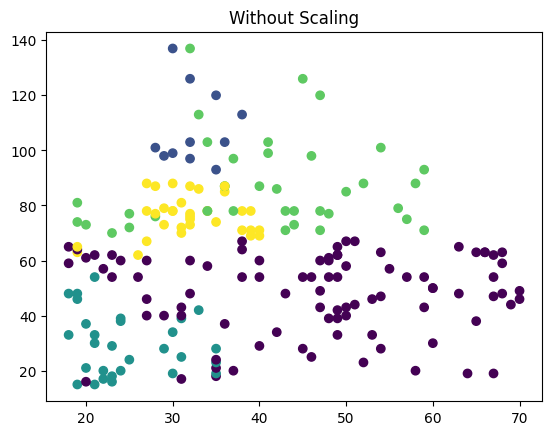

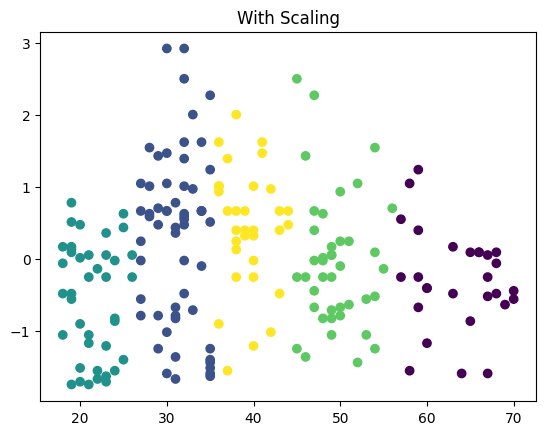

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Mall_Customers.csv")
X = df.drop("CustomerID", axis=1)
X = pd.get_dummies(X, drop_first=True)

kmeans1 = KMeans(n_clusters=5, random_state=42)
labels1 = kmeans1.fit_predict(X)

plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels1)
plt.title("Without Scaling")
plt.show()

X_scaled = X.copy()

scaler = StandardScaler()
cols_to_scale = X_scaled.columns.drop("Age")

X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

kmeans2 = KMeans(n_clusters=5, random_state=42)
labels2 = kmeans2.fit_predict(X_scaled)

plt.scatter(X_scaled.iloc[:,0], X_scaled.iloc[:,1], c=labels2)
plt.title("With Scaling")
plt.show()

In [3]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'vehicle_serial_no': [5,3,8,2,4,7,6,10,1,9],
    'mileage': [150000,120000,250000,80000,100000,220000,180000,300000,75000,280000],
    'fuel_efficiency': [15,18,10,22,20,12,16,8,24,9],
    'maintenance_cost': [5000,4000,7000,2000,3000,6500,5500,8000,1500,7500],
    'vehicle_type': ['SUV','Sedan','Truck','Hatchback','Sedan','Truck','SUV','Truck','Hatchback','SUV']
}

df = pd.DataFrame(data)
df_encoded = pd.get_dummies(df, columns=['vehicle_type'])

kmeans1 = KMeans(n_clusters=3, random_state=42)
labels1 = kmeans1.fit_predict(df_encoded)

df['Cluster_NoScaling'] = labels1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

kmeans2 = KMeans(n_clusters=3, random_state=42)
labels2 = kmeans2.fit_predict(X_scaled)

df['Cluster_Scaling'] = labels2

print(df)

   vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost vehicle_type  \
0                  5   150000               15              5000          SUV   
1                  3   120000               18              4000        Sedan   
2                  8   250000               10              7000        Truck   
3                  2    80000               22              2000    Hatchback   
4                  4   100000               20              3000        Sedan   
5                  7   220000               12              6500        Truck   
6                  6   180000               16              5500          SUV   
7                 10   300000                8              8000        Truck   
8                  1    75000               24              1500    Hatchback   
9                  9   280000                9              7500          SUV   

   Cluster_NoScaling  Cluster_Scaling  
0                  2                1  
1                  2        

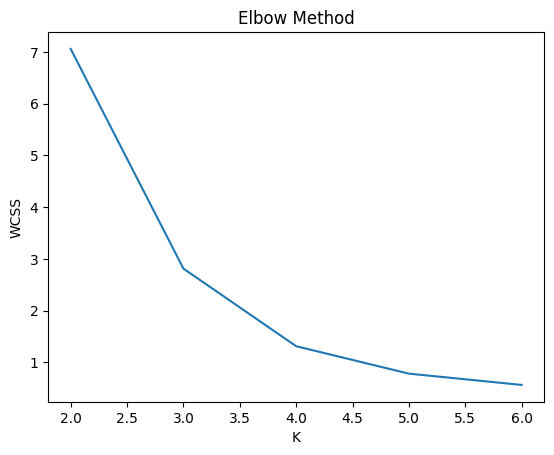

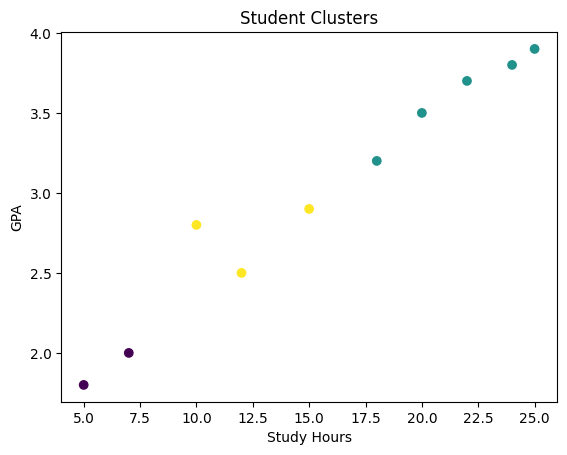

   student_id  GPA  study_hours  attendance_rate  Cluster
0           1  3.5           20               90        1
1           2  2.8           10               70        2
2           3  3.9           25               95        1
3           4  1.8            5               60        0
4           5  2.5           12               75        2
5           6  3.2           18               85        1
6           7  3.7           22               92        1
7           8  2.0            7               65        0
8           9  2.9           15               80        2
9          10  3.8           24               96        1


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Used gpt to create a sample dataset
data = {
    'student_id': [1,2,3,4,5,6,7,8,9,10],
    'GPA': [3.5,2.8,3.9,1.8,2.5,3.2,3.7,2.0,2.9,3.8],
    'study_hours': [20,10,25,5,12,18,22,7,15,24],
    'attendance_rate': [90,70,95,60,75,85,92,65,80,96]
}
df = pd.DataFrame(data)

X = df[['GPA','study_hours','attendance_rate']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(2,7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,7), wcss)
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = labels

plt.scatter(df['study_hours'], df['GPA'], c=labels)
plt.xlabel("Study Hours")
plt.ylabel("GPA")
plt.title("Student Clusters")
plt.show()

print(df)